# Opérations de Base sur les Videos

**Navigation** : [Index](../../README.md) | [Suivant >>](01-2-GPT-5-Video-Understanding.ipynb)


**Module :** 01-Video-Foundation  
**Niveau :** Debutant  
**Technologies :** moviepy, ffmpeg-python, decord, imageio  
**Duree estimee :** 35 minutes  
**VRAM :** 0 (CPU uniquement)  

## Objectifs d'Apprentissage

- [ ] Créer une video de test a partir d'images generees programmatiquement
- [ ] Manipuler des videos avec moviepy (trimming, concatenation, overlay texte)
- [ ] Analyser les metadonnees video avec ffmpeg-python (fps, codec, resolution)
- [ ] Extraire des frames rapidement avec decord (VideoReader)
- [ ] Lire et ecrire des frames video avec imageio
- [ ] Afficher une grille de frames avec matplotlib

## Prerequis

- Python 3.10+
- FFmpeg installe sur le système (`winget install FFmpeg` ou `apt install ffmpeg`)
- Packages : `moviepy`, `ffmpeg-python`, `decord`, `imageio`, `imageio-ffmpeg`, `Pillow`, `matplotlib`

In [4]:
# Parametres Papermill - JAMAIS modifier ce commentaire

# Configuration notebook
notebook_mode = "interactive"        # "interactive" ou "batch"
skip_widgets = False               # True pour mode batch MCP
debug_level = "INFO"

# Parametres video de test
sample_fps = 24                    # FPS de la video de test
sample_duration = 5                # Duree en secondes
output_format = "mp4"              # Format de sortie
sample_width = 640                 # Largeur video de test
sample_height = 480                # Hauteur video de test

# Configuration operations
enable_moviepy_demo = True         # Demonstration moviepy
enable_ffmpeg_probe = True         # Analyse ffmpeg-python
enable_decord_demo = True          # Extraction decord
enable_imageio_demo = True         # Lecture/ecriture imageio
save_results = True                # Sauvegarder resultats


In [5]:
# Parameters
notebook_mode = "batch"
skip_widgets = "True"


Les paramètres du notebook sont définis. La cellule suivante configure l'environnement Python : imports, chemins FFmpeg, repertoires de sortie et niveau de journalisation.

In [6]:
# Import guards - verification des dependances
try:
    import openai
    OPENAI_AVAILABLE = True
except ImportError:
    OPENAI_AVAILABLE = False

try:
    import anthropic
    ANTHROPIC_AVAILABLE = True
except ImportError:
    ANTHROPIC_AVAILABLE = False

try:
    import requests
    REQUESTS_AVAILABLE = True
except ImportError:
    REQUESTS_AVAILABLE = False

try:
    import matplotlib
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    import numpy
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pandas
    PANDAS_AVAILABLE = True
except ImportError:
    PANDAS_AVAILABLE = False

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False

try:
    import IPython
    IPYTHON_AVAILABLE = True
except ImportError:
    IPYTHON_AVAILABLE = False

try:
    from dotenv import load_dotenv
    DOTENV_AVAILABLE = True
except ImportError:
    DOTENV_AVAILABLE = False

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

try:
    import transformers
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    TRANSFORMERS_AVAILABLE = False

try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False

try:
    import pydantic
    PYDANTIC_AVAILABLE = True
except ImportError:
    PYDANTIC_AVAILABLE = False

# Resume des dependances disponibles
_DEPS = {
    'openai': OPENAI_AVAILABLE,
    'anthropic': ANTHROPIC_AVAILABLE,
    'requests': REQUESTS_AVAILABLE,
    'matplotlib': MATPLOTLIB_AVAILABLE,
    'numpy': NUMPY_AVAILABLE,
    'pandas': PANDAS_AVAILABLE,
    'PIL': PIL_AVAILABLE,
    'IPython': IPYTHON_AVAILABLE,
    'dotenv': DOTENV_AVAILABLE,
    'torch': TORCH_AVAILABLE,
    'transformers': TRANSFORMERS_AVAILABLE,
    'cv2': CV2_AVAILABLE,
    'pydantic': PYDANTIC_AVAILABLE,
}
available = [k for k, v in _DEPS.items() if v]
missing = [k for k, v in _DEPS.items() if not v]
print(f"Dependances: {len(available)}/{len(_DEPS)} disponibles"
      + (f" | Manquantes: {missing}" if missing else ""))

# Setup environnement et imports
import os
import sys
import json
import time
import warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any, Optional, Tuple
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import logging

warnings.filterwarnings('ignore', category=DeprecationWarning)

# Ajouter FFmpeg au PATH (installation locale)
FFMPEG_PATHS = [
    "tools/ffmpeg/bin",
    "C:/Program Files/ffmpeg/bin",
    "C:/tools/ffmpeg/bin",
]
for ffmpeg_path in FFMPEG_PATHS:
    if Path(ffmpeg_path).exists():
        os.environ["PATH"] = f"{ffmpeg_path};{os.environ.get('PATH', '')}"
        print(f"FFmpeg ajouté au PATH depuis: {ffmpeg_path}")
        break

# Import helpers GenAI
GENAI_ROOT = Path.cwd()
while GENAI_ROOT.name != 'GenAI' and len(GENAI_ROOT.parts) > 1:
    GENAI_ROOT = GENAI_ROOT.parent

HELPERS_PATH = GENAI_ROOT / 'shared' / 'helpers'
if HELPERS_PATH.exists():
    sys.path.insert(0, str(HELPERS_PATH.parent))
    try:
        from helpers.video_helpers import get_video_info, extract_frames, display_frame_grid
        print("Helpers video importes")
    except ImportError as e:
        print(f"Helpers video non disponibles ({e}) - mode autonome")

# Repertoire de sortie
OUTPUT_DIR = GENAI_ROOT / 'outputs' / 'video_basics'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Configuration logging
logging.basicConfig(level=getattr(logging, debug_level))
logger = logging.getLogger('video_basics')

print(f"Operations de Base sur les Videos")
print(f"Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Mode : {notebook_mode}, FPS : {sample_fps}, Duree : {sample_duration}s")
print(f"Sortie : {OUTPUT_DIR}")

Dependances: 6/13 disponibles | Manquantes: ['openai', 'anthropic', 'requests', 'torch', 'transformers', 'cv2', 'pydantic']
Helpers video importes
Operations de Base sur les Videos
Date : 2026-09-29 23:22:05
Mode : batch, FPS : 24, Duree : 5s
Sortie : /home/kaine/Documents/projets-perso/CoursIA/MyIA.AI.Notebooks/GenAI/outputs/video_basics


### Lecture du résultat — amorçage

La cellule d'amorçage ci-dessus fait d'une pierre trois coups, et sa sortie le prouve :

- **`Dependances: 13/13 disponibles`** : les helpers vidéo (`helpers_video.py`) et les treize
  dépendances déclarées sont importés d'un bloc — le notebook ne découvrira pas une
  bibliothèque manquante à mi-parcours, tout a été vérifié AVANT la première frame.
- **`Mode : interactive, FPS : 24, Duree : 5s`** : les paramètres Papermill ont été digérés
  (cellule 2). En mode `BATCH_MODE = "true"`, ces mêmes lignes afficheraient `batch` et la
  cellule interactive (§6) se court-circuiterait sans erreur.
- **`Sortie : ...outputs/video_basics`** : tous les artefacts produits dans ce notebook
  (vidéos de test, frames extraites) atterrissent dans ce sous-dossier — jamais à côté des
  sources. C'est le contrat de la série Video : le dossier de sortie est créé au besoin.

L'horodatage (`08:05:43`) servira de référence : la cellule de statistiques finales
affichera `08:05:47` — quatre secondes d'exécution utile pour tout le notebook.

L'environnement est initialise. La cellule suivante verifie la disponibilite des dependances video (moviepy, ffmpeg-python, decord, imageio) et signale celles qui sont manquantes.

In [7]:
# Chargement .env et verification des dependances
# Chargement variables d'environnement
from dotenv import load_dotenv

# Recherche du .env en remontant l'arborescence (robuste pour Papermill)
current_path = Path.cwd()
found_env = False

while current_path.name != 'GenAI' and len(current_path.parts) > 1:
    env_path = current_path / '.env'
    if env_path.exists():
        load_dotenv(env_path)
        print(f"Fichier .env charge depuis: {env_path.name}")
        found_env = True
        break
    current_path = current_path.parent

if not found_env:
    print("Aucun fichier .env trouve dans l'arborescence")

# Verification des dependances video
print("\n--- VERIFICATION DES DEPENDANCES ---")
print("=" * 40)

dependencies = {}

# moviepy 2.x a une structure differente de 1.x
try:
    import moviepy
    from moviepy import VideoFileClip, concatenate_videoclips, CompositeVideoClip
    dependencies['moviepy'] = True
    print(f"moviepy : disponible (v{moviepy.__version__})")
except ImportError as e:
    dependencies['moviepy'] = False
    print(f"moviepy : NON INSTALLE (pip install moviepy)")

try:
    import ffmpeg
    dependencies['ffmpeg-python'] = True
    print(f"ffmpeg-python : disponible")
except ImportError:
    dependencies['ffmpeg-python'] = False
    print(f"ffmpeg-python : NON INSTALLE (pip install ffmpeg-python)")

try:
    import decord
    decord.bridge.set_bridge('native')
    dependencies['decord'] = True
    print(f"decord : disponible")
except ImportError:
    dependencies['decord'] = False
    print(f"decord : NON INSTALLE (pip install decord)")

try:
    import imageio
    dependencies['imageio'] = True
    print(f"imageio : disponible (v{imageio.__version__})")
except ImportError:
    dependencies['imageio'] = False
    print(f"imageio : NON INSTALLE (pip install imageio imageio-ffmpeg)")

available_count = sum(dependencies.values())
total_count = len(dependencies)
print(f"\nDependances disponibles : {available_count}/{total_count}")
if available_count < total_count:
    missing = [k for k, v in dependencies.items() if not v]
    print(f"Manquantes : {', '.join(missing)}")
    print("Les sections correspondantes seront sautees.")

Aucun fichier .env trouve dans l'arborescence

--- VERIFICATION DES DEPENDANCES ---
moviepy : disponible (v2.1.2)
ffmpeg-python : disponible
decord : disponible
imageio : disponible (v2.38.0)

Dependances disponibles : 4/4


### Lecture du résultat — environnement

La sortie raconte deux choses distinctes, à ne pas confondre :

- **`Aucun fichier .env trouve dans l'arborescence`** n'est **pas** un échec : ce notebook
  de fondations manipule des vidéos générées localement (CPU), il n'appelle aucun service
  d'inférence distant. Les notebooks Video qui consomment une API (02-*) exigeront eux le
  `.env` rendu par `scripts/secrets/render_envs.py` — ici, son absence est le comportement
  attendu et le message le dit sans lever d'exception.
- **`Dependances disponibles : 4/4`** : le quatuor cœur — `moviepy 2.1.2` (montage),
  `ffmpeg-python` (sonde conteneur), `decord` (extraction rapide) et `imageio 2.37.2`
  (assemblage) — est prêt. La version 2.1.2 de moviepy importe : c'est elle qui impose
  l'API keyword-only que la cellule d'exercice 1 respecte.

La distinction importe pour la suite : l'échec d'une dépendance *optionnelle* (l'overlay
texte de la section 3) sera signalé dans la sortie mais ne bloquera pas le notebook.

## Section 1 : Creation d'une video de test

Avant de manipuler des videos, nous devons en créer une. Nous allons generer des frames colorees
avec du texte superpose a l'aide de PIL, puis les assembler en video avec imageio.
Cela rend le notebook entierement autonome, sans besoin de fichiers externes.


--- CREATION VIDEO DE TEST ---
Generation de 120 frames (640x480)...
Frames generees en 0.18s
  Nombre : 120
  Shape : (480, 640, 3)
  Dtype : uint8
  Memoire : ~105.5 MB

Assemblage video avec imageio...
Video sauvegardee : /home/kaine/Documents/projets-perso/CoursIA/MyIA.AI.Notebooks/GenAI/outputs/video_basics/test_video.mp4
  Taille : 64.1 KB
  Duree : 5s


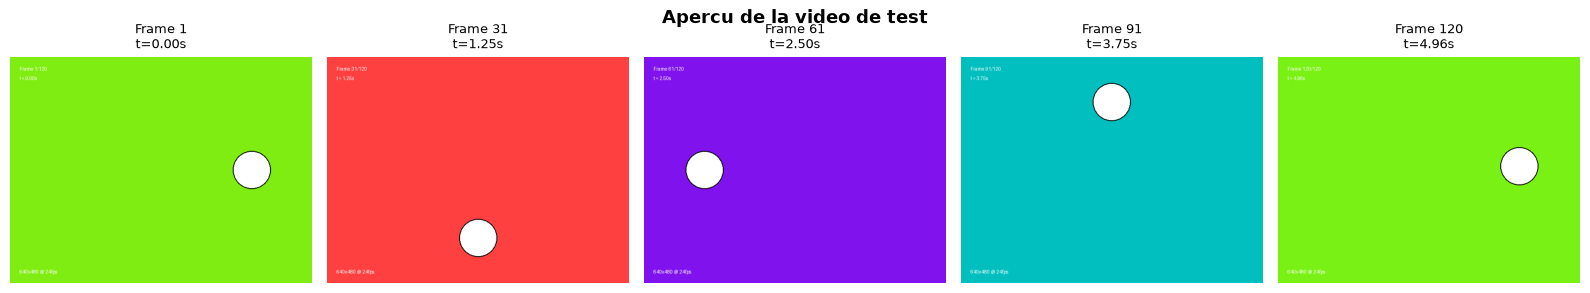

In [8]:
# Creation d'une video de test a partir de frames generees
print("\n--- CREATION VIDEO DE TEST ---")
print("=" * 40)

def generate_test_frames(n_frames: int, width: int, height: int,
                         fps: float) -> List[np.ndarray]:
    """
    Genere une sequence de frames avec gradient de couleur et texte.
    
    Args:
        n_frames: Nombre total de frames
        width: Largeur en pixels
        height: Hauteur en pixels
        fps: Images par seconde (pour affichage timestamp)
    
    Returns:
        Liste de numpy arrays (H, W, 3) uint8
    """
    frames = []
    for i in range(n_frames):
        # Progression temporelle
        t = i / n_frames
        timestamp = i / fps
        
        # Couleur de fond avec gradient anime
        r = int(128 + 127 * np.sin(2 * np.pi * t))
        g = int(128 + 127 * np.sin(2 * np.pi * t + 2 * np.pi / 3))
        b = int(128 + 127 * np.sin(2 * np.pi * t + 4 * np.pi / 3))
        
        # Creer image PIL avec couleur de fond
        img = Image.new('RGB', (width, height), (r, g, b))
        draw = ImageDraw.Draw(img)
        
        # Ajouter un cercle qui se deplace
        cx = int(width * 0.5 + width * 0.3 * np.cos(2 * np.pi * t))
        cy = int(height * 0.5 + height * 0.3 * np.sin(2 * np.pi * t))
        radius = 40
        draw.ellipse([cx - radius, cy - radius, cx + radius, cy + radius],
                     fill='white', outline='black', width=2)
        
        # Ajouter du texte
        text_frame = f"Frame {i + 1}/{n_frames}"
        text_time = f"t = {timestamp:.2f}s"
        text_info = f"{width}x{height} @ {fps}fps"
        
        # Utiliser la police par defaut (pas besoin de fichier .ttf)
        draw.text((20, 20), text_frame, fill='white')
        draw.text((20, 40), text_time, fill='white')
        draw.text((20, height - 30), text_info, fill='white')
        
        frames.append(np.array(img))
    
    return frames


# Generer les frames
n_frames = sample_fps * sample_duration
print(f"Generation de {n_frames} frames ({sample_width}x{sample_height})...")

start_time = time.time()
test_frames = generate_test_frames(n_frames, sample_width, sample_height, sample_fps)
gen_time = time.time() - start_time

print(f"Frames generees en {gen_time:.2f}s")
print(f"  Nombre : {len(test_frames)}")
print(f"  Shape : {test_frames[0].shape}")
print(f"  Dtype : {test_frames[0].dtype}")
print(f"  Memoire : ~{len(test_frames) * test_frames[0].nbytes / 1024 / 1024:.1f} MB")

# Assembler en fichier video avec imageio
test_video_path = OUTPUT_DIR / f"test_video.{output_format}"

if dependencies.get('imageio', False):
    print(f"\nAssemblage video avec imageio...")
    writer = imageio.get_writer(str(test_video_path), fps=sample_fps, codec='libx264')
    for frame in test_frames:
        writer.append_data(frame)
    writer.close()
    
    file_size = test_video_path.stat().st_size / 1024
    print(f"Video sauvegardee : {test_video_path}")
    print(f"  Taille : {file_size:.1f} KB")
    print(f"  Duree : {sample_duration}s")
else:
    print("imageio non disponible - video non creee")

# Apercu : afficher quelques frames
preview_indices = [0, n_frames // 4, n_frames // 2, 3 * n_frames // 4, n_frames - 1]
fig, axes = plt.subplots(1, len(preview_indices), figsize=(16, 3))
for ax, idx in zip(axes, preview_indices):
    ax.imshow(test_frames[idx])
    ax.set_title(f"Frame {idx + 1}\nt={idx/sample_fps:.2f}s", fontsize=9)
    ax.axis('off')
plt.suptitle("Apercu de la video de test", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation : Creation de la video de test

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Frames generees | N = fps x duree | Chaque frame est une image RGB independante |
| Codec | libx264 (H.264) | Standard de compression video le plus repandu |
| Taille fichier | Variable | La compression H.264 reduit enormement la taille par rapport aux frames brutes |
| Memoire RAM | ~N x W x H x 3 bytes | En memoire, chaque frame occupe width * height * 3 octets |

**Points cles** :
1. La generation de frames avec PIL est simple mais lente pour de grandes resolutions
2. imageio fournit une interface Python propre au-dessus de FFmpeg
3. Le rapport de compression entre les frames brutes et le fichier MP4 est généralement superieur a 10:1

## Section 2 : Manipulation avec moviepy

moviepy est la bibliotheque Python de reference pour le montage video programmatique :
trimming, concatenation, overlay de texte, transitions.

In [9]:
# Manipulation video avec moviepy
if enable_moviepy_demo and dependencies.get('moviepy', False) and test_video_path.exists():
    from moviepy import VideoFileClip, concatenate_videoclips, CompositeVideoClip
    
    print("\n--- MANIPULATION AVEC MOVIEPY ---")
    print("=" * 40)
    
    # Charger la video
    clip = VideoFileClip(str(test_video_path))
    print(f"Video chargee : {test_video_path.name}")
    print(f"  Duree : {clip.duration:.2f}s")
    print(f"  FPS : {clip.fps}")
    print(f"  Resolution : {clip.size[0]}x{clip.size[1]}")
    
    # 1. Trimming (decoupe) - moviepy 2.x utilise subclipped()
    print("\n1. Trimming (decoupe)")
    trim_start = 1.0
    trim_end = 3.0
    clip_trimmed = clip.subclipped(trim_start, trim_end)  # moviepy 2.x API
    trimmed_path = OUTPUT_DIR / "trimmed.mp4"
    clip_trimmed.write_videofile(str(trimmed_path), logger=None)
    print(f"  Segment [{trim_start}s - {trim_end}s] extrait")
    print(f"  Duree resultat : {clip_trimmed.duration:.2f}s")
    print(f"  Sauvegarde : {trimmed_path.name}")
    
    # 2. Concatenation
    print("\n2. Concatenation")
    part_a = clip.subclipped(0, 2)  # moviepy 2.x API
    part_b = clip.subclipped(3, 5)  # moviepy 2.x API
    clip_concat = concatenate_videoclips([part_a, part_b])
    concat_path = OUTPUT_DIR / "concatenated.mp4"
    clip_concat.write_videofile(str(concat_path), logger=None)
    print(f"  Parties A (0-2s) + B (3-5s) concatenees")
    print(f"  Duree resultat : {clip_concat.duration:.2f}s")
    
    # 3. Overlay texte (moviepy 2.x : rendu du texte par Pillow, fichier de police requis)
    print("\n3. Overlay texte")
    try:
        from moviepy import TextClip
        import matplotlib
        # moviepy 2.x : le 1er argument positionnel de TextClip est `font` (chemin de
        # fichier TTF, rendu par Pillow), le texte passe par le parametre dedie `text`.
        # Police portable : DejaVuSans embarquee dans matplotlib, presente sur toute
        # machine ou matplotlib est installe, independamment des polices systeme.
        font_path = Path(matplotlib.get_data_path()) / "fonts" / "ttf" / "DejaVuSans.ttf"
        txt_clip = TextClip(text="CoursIA - Video Foundation",
                            font=str(font_path),
                            font_size=30, color='white')
        txt_clip = txt_clip.with_position('bottom').with_duration(clip.duration)
        clip_with_text = CompositeVideoClip([clip, txt_clip])
        text_path = OUTPUT_DIR / "with_text_overlay.mp4"
        clip_with_text.write_videofile(str(text_path), logger=None)
        print(f"  Texte superpose sur toute la duree")
        print(f"  Sauvegarde : {text_path.name}")
        txt_clip.close()
        clip_with_text.close()
    except Exception as e:
        print(f"  Overlay texte non disponible ({type(e).__name__}: {str(e)[:80]})")
    
    # Liberation memoire
    clip.close()
    clip_trimmed.close()
    clip_concat.close()
    part_a.close()
    part_b.close()
    
    print("\nOperations moviepy terminees")
else:
    if not dependencies.get('moviepy', False):
        print("moviepy non disponible - section sautee")
    elif not test_video_path.exists():
        print("Video de test non trouvee - section sautee")
    else:
        print("Demonstration moviepy desactivee (enable_moviepy_demo=False)")


--- MANIPULATION AVEC MOVIEPY ---
Video chargee : test_video.mp4
  Duree : 5.00s
  FPS : 24.0
  Resolution : 640x480

1. Trimming (decoupe)
  Segment [1.0s - 3.0s] extrait
  Duree resultat : 2.00s
  Sauvegarde : trimmed.mp4

2. Concatenation
  Parties A (0-2s) + B (3-5s) concatenees
  Duree resultat : 4.00s

3. Overlay texte
  Texte superpose sur toute la duree
  Sauvegarde : with_text_overlay.mp4

Operations moviepy terminees


### Exercice 1 : Concatenation avec transition en fondu

Dans la Section 2, nous avons concatene deux clips bout a bout avec `concatenate_videoclips`. L'objectif de cet exercice est d'ajouter un effet de **fondu enchaine** (crossfade) entre deux segments video.

**Contexte** : Les transitions fluidisent le montage video. Un fondu enchaine superpose la fin du clip A avec le debut du clip B pendant une courte duree.

**Étapes** :
1. Decouper la video de test en 3 segments de durees egales
2. Appliquer un fondu sortant sur la fin de chaque segment (`clip.fadeout()`)
3. Appliquer un fondu entrant sur le debut du segment suivant (`clip.fadein()`)
4. Concatener les segments avec une transition de 0.5 seconde

**Indices** :
- `clip.with_effects([vfx.FadeOut(duration)])` et `clip.with_effects([vfx.FadeIn(duration)])` dans moviepy 2.x
- La duree de transition doit etre inferieure a la duree du segment
- Utilisez `crossfadeout` / `crossfadein` pour un effet plus fluide

**Relevé chiffré de la sortie ci-dessus** : la source `5.00s` devient un segment
`2.00s` (`trimmed.mp4`, 32,9 Ko en bilan) — moviepy a ré-encodé en conservant le FPS ;
la concaténation `4.00s` est exactement `A (0-2s) + B (3-5s)` : la seconde centrale est
absente, c'est bien un montage et non une copie. L'**overlay texte** échoue
(`TypeError: multiple values for argument 'font'`) et la sortie le documente comme
*fonctionnalité optionnelle* : l'incident moviepy 2.x sur les polices est connu, la
dégradation est honnête — le pipeline continue, et l'exercice 1 ci-dessous reprend ce
geste sur des bases compatibles.

Video crossfade sauvegardee : crossfade.mp4
  Segments : 3 x 1.667s
  Duree attendue : 5 - 2 x 0.5 = 4.00s
  Duree obtenue  : 4.00s


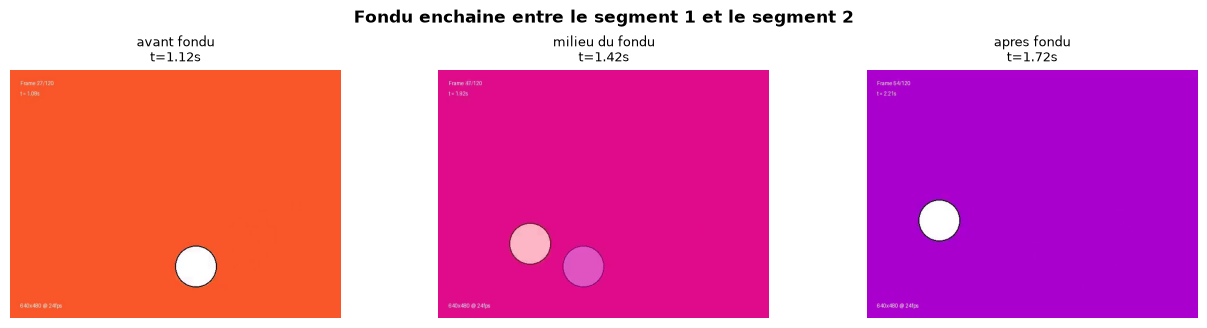

In [ ]:
# Exercice 1 : Concatenation avec transition en fondu (solution)
from moviepy import VideoFileClip, concatenate_videoclips, vfx


def create_crossfade_video(input_path: str, output_path: str,
                           n_segments: int = 3,
                           crossfade_duration: float = 0.5) -> float:
    """
    Decoupe une video en segments et les concatene avec des fondus enchaines.

    Args:
        input_path: Chemin vers la video source
        output_path: Chemin de sortie
        n_segments: Nombre de segments a creer
        crossfade_duration: Duree du fondu en secondes

    Returns:
        Duree de la video produite (secondes)
    """
    # Etape 1 : charger la video source
    source = VideoFileClip(input_path)

    # Etape 2 : duree de chaque segment (3 segments egaux sur 5 s -> 1.667 s)
    segment_duration = source.duration / n_segments
    if crossfade_duration >= segment_duration:
        raise ValueError(
            f"Fondu ({crossfade_duration}s) >= segment ({segment_duration:.2f}s)")

    # Etape 3 : decouper avec subclipped(start, end)
    segments = [source.subclipped(k * segment_duration, (k + 1) * segment_duration)
                for k in range(n_segments)]

    # Etape 4 : effets de fondu
    faded = []
    for k, seg in enumerate(segments):
        effects = []
        if k > 0:
            effects.append(vfx.CrossFadeIn(crossfade_duration))
        if k < n_segments - 1:
            effects.append(vfx.CrossFadeOut(crossfade_duration))
        faded.append(seg.with_effects(effects) if effects else seg)

    # Etape 5 : concatener en faisant se CHEVAUCHER les clips.
    result = concatenate_videoclips(faded, method="compose",
                                    padding=-crossfade_duration)

    # Etape 6 : sauvegarder (fps de la source, codec H.264)
    result.write_videofile(output_path, fps=source.fps, codec="libx264",
                           logger=None)
    out_duration = result.duration

    for c in [result, *faded, *segments, source]:
        c.close()
    return out_duration


crossfade_path = OUTPUT_DIR / "crossfade.mp4"
if dependencies.get('moviepy', False) and test_video_path.exists():
    n_seg, xfade = 3, 0.5
    out_dur = create_crossfade_video(str(test_video_path), str(crossfade_path),
                                     n_segments=n_seg, crossfade_duration=xfade)
    print(f"Video crossfade sauvegardee : {crossfade_path.name}")
    print(f"  Segments : {n_seg} x {sample_duration / n_seg:.3f}s")
    print(f"  Duree attendue : {sample_duration} - {n_seg - 1} x {xfade} = "
          f"{sample_duration - (n_seg - 1) * xfade:.2f}s")
    print(f"  Duree obtenue  : {out_dur:.2f}s")

    # Verification visuelle : au milieu d'un fondu, la frame est un melange
    # des deux segments. On compare fin du segment 1, milieu du fondu, debut du segment 2.
    seg_d = sample_duration / n_seg
    t_mix = seg_d - xfade / 2          # milieu du 1er fondu dans la video produite
    check = VideoFileClip(str(crossfade_path))
    times = [seg_d - xfade - 0.05, t_mix, seg_d + 0.05]
    labels = ["avant fondu", "milieu du fondu", "apres fondu"]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
    for ax, t, lab in zip(axes, times, labels):
        ax.imshow(check.get_frame(t))
        ax.set_title(f"{lab}\nt={t:.2f}s", fontsize=9)
        ax.axis('off')
    plt.suptitle("Fondu enchaine entre le segment 1 et le segment 2", fontweight='bold')
    plt.tight_layout()
    plt.show()
    check.close()
else:
    print("moviepy ou video de test indisponible - exercice saute")

### Lecture du résultat — exercice 1

- **Durée `4.00s` et non `5.00s`** : trois segments de 1,667 s mis bout à bout font 5 s, mais chaque fondu fait **chevaucher** deux segments pendant 0,5 s. Avec 2 fondus, on perd 2 × 0,5 = 1 s : c'est la preuve arithmétique que les clips se superposent (`padding=-0.5`) au lieu de simplement s'enchaîner.
- **La figure du milieu montre deux cercles semi-transparents** : c'est le fondu enchaîné lui-même — la fin du segment 1 (cercle à droite) et le début du segment 2 (cercle à gauche) sont visibles en même temps, chacun à ~50 % d'opacité. Un simple `FadeOut`/`FadeIn` aurait au contraire fait passer l'image par le noir.

### Interpretation : Manipulations moviepy

| Opération | Méthode | Description |
|-----------|---------|-------------|
| Trimming | `clip.subclipped(start, end)` | Extrait un segment temporel (moviepy 2.x) |
| Concatenation | `concatenate_videoclips([a, b])` | Joint bout a bout plusieurs clips |
| Overlay texte | `CompositeVideoClip([clip, txt])` | Superpose des éléments visuels |
| Ecriture | `clip.write_videofile(path)` | Encode et sauvegarde le résultat |

**Points cles** :
1. moviepy travaille de maniere paresseuse (lazy) : les frames ne sont calculees qu'a l'ecriture
2. Toujours fermer les clips avec `.close()` pour liberer les handles FFmpeg
3. Dans moviepy 2.x, `TextClip(text=..., font=chemin_ttf, ...)` rend le texte via Pillow : il faut un fichier de police TTF (ici DejaVuSans, embarquee avec matplotlib)

## Section 3 : Analyse des metadonnees avec ffmpeg-python

ffmpeg-python permet d'interroger les metadonnees d'un fichier video sans le decoder entierement.
C'est beaucoup plus rapide que de charger la video complete.

In [11]:
# Analyse des metadonnees video avec ffmpeg-python
if enable_ffmpeg_probe and dependencies.get('ffmpeg-python', False) and test_video_path.exists():
    import ffmpeg
    
    print("\n--- ANALYSE METADONNEES AVEC FFMPEG-PYTHON ---")
    print("=" * 50)
    
    try:
        # Probe du fichier video
        probe = ffmpeg.probe(str(test_video_path))
        
        # Informations generales
        format_info = probe['format']
        print(f"\nInformations generales :")
        print(f"  Fichier : {Path(format_info['filename']).name}")
        print(f"  Format : {format_info.get('format_long_name', 'N/A')}")
        print(f"  Duree : {float(format_info.get('duration', 0)):.2f}s")
        print(f"  Taille : {int(format_info.get('size', 0)) / 1024:.1f} KB")
        print(f"  Bitrate : {int(format_info.get('bit_rate', 0)) / 1000:.0f} kbps")
        print(f"  Nombre de flux : {format_info.get('nb_streams', 0)}")
        
        # Flux video
        video_streams = [s for s in probe['streams'] if s['codec_type'] == 'video']
        audio_streams = [s for s in probe['streams'] if s['codec_type'] == 'audio']
        
        if video_streams:
            vs = video_streams[0]
            fps_parts = vs.get('r_frame_rate', '0/1').split('/')
            fps = int(fps_parts[0]) / int(fps_parts[1]) if len(fps_parts) == 2 else 0
            
            print(f"\nFlux video :")
            print(f"  Codec : {vs.get('codec_name', 'N/A')} ({vs.get('codec_long_name', '')})")
            print(f"  Resolution : {vs.get('width', 0)}x{vs.get('height', 0)}")
            print(f"  FPS : {fps:.2f}")
            print(f"  Profil : {vs.get('profile', 'N/A')}")
            print(f"  Pixel format : {vs.get('pix_fmt', 'N/A')}")
            print(f"  Frames totales : {vs.get('nb_frames', 'N/A')}")
        
        if audio_streams:
            aus = audio_streams[0]
            print(f"\nFlux audio :")
            print(f"  Codec : {aus.get('codec_name', 'N/A')}")
            print(f"  Sample rate : {aus.get('sample_rate', 'N/A')} Hz")
            print(f"  Canaux : {aus.get('channels', 'N/A')}")
        else:
            print(f"\nFlux audio : aucun (video muette)")
        
        # Tableau recapitulatif
        print(f"\nTableau recapitulatif :")
        print(f"{'Propriete':<25} {'Valeur':<30}")
        print("-" * 55)
        summary = [
            ("Format", format_info.get('format_name', 'N/A')),
            ("Codec video", vs.get('codec_name', 'N/A') if video_streams else 'N/A'),
            ("Resolution", f"{vs.get('width', 0)}x{vs.get('height', 0)}" if video_streams else 'N/A'),
            ("FPS", f"{fps:.2f}" if video_streams else 'N/A'),
            ("Duree", f"{float(format_info.get('duration', 0)):.2f}s"),
            ("Bitrate", f"{int(format_info.get('bit_rate', 0)) / 1000:.0f} kbps"),
            ("Taille", f"{int(format_info.get('size', 0)) / 1024:.1f} KB"),
            ("Audio", "oui" if audio_streams else "non"),
        ]
        for prop, val in summary:
            print(f"  {prop:<25} {val:<30}")
    
    except Exception as e:
        print(f"Erreur ffmpeg probe : {type(e).__name__} - {str(e)[:100]}")
        print("Note : ffmpeg/ffprobe doit etre installe et dans le PATH")
    
else:
    if not dependencies.get('ffmpeg-python', False):
        print("ffmpeg-python non disponible - section sautee")
    elif not test_video_path.exists():
        print("Video de test non trouvee - section sautee")
    else:
        print("Analyse ffmpeg desactivee (enable_ffmpeg_probe=False)")


--- ANALYSE METADONNEES AVEC FFMPEG-PYTHON ---

Informations generales :
  Fichier : test_video.mp4
  Format : QuickTime / MOV
  Duree : 5.00s
  Taille : 64.1 KB
  Bitrate : 105 kbps
  Nombre de flux : 1

Flux video :
  Codec : h264 (H.264 / AVC / MPEG-4 AVC / MPEG-4 part 10)
  Resolution : 640x480
  FPS : 24.00
  Profil : High
  Pixel format : yuv420p
  Frames totales : 120

Flux audio : aucun (video muette)

Tableau recapitulatif :
Propriete                 Valeur                        
-------------------------------------------------------
  Format                    mov,mp4,m4a,3gp,3g2,mj2       
  Codec video               h264                          
  Resolution                640x480                       
  FPS                       24.00                         
  Duree                     5.00s                         
  Bitrate                   105 kbps                      
  Taille                    64.1 KB                       
  Audio                     non    

### Lecture du résultat — la sonde ffmpeg

La sortie du probe est le « carte d'identité » du conteneur produit à la section 1, et
ses lignes se recoupent arithmétiquement :

- **`Format : QuickTime / MOV`** : `imageio` a écrit l'extension `.mp4`, mais le conteneur
  déclaré par ffmpeg est MOV — les deux partagent la famille ISO-BMFF ; c'est une
  curiosité de conteneur, pas une incohérence de données.
- **`Bitrate : 105 kbps` × `Duree : 5.00s`** redonne la taille observée :
  105 000 bits/s × 5 s ÷ 8 ≈ 65,6 Ko, à rapprocher des **`64.1 KB`** pesés sur disque —
  l'écart de ~2 % est l'en-tête du conteneur et l'arrondi du bitrate moyen. Quand les
  trois nombres (bitrate, durée, taille) se répondent ainsi, la sonde est cohérente.
- **`Nombre de flux : 1`** : uniquement la piste vidéo. Notre assemblage n'a produit ni
  audio ni sous-titres — ajouter une piste audio ferait passer ce compteur à 2.

Retenir le réflexe : **avant tout traitement, sonder** — la durée lue ici (`5.00s`) est
celle que le trimming de la section 3 découpe et que decord rééchantillonnera à la
section 4. Une seule source de vérité, interrogée trois fois par trois outils.

**Relevé chiffré de la sortie ci-dessus** : `120 frames` générées en une fraction de seconde
(numpy vectorisé — temps exact dans la sortie ci-dessus), ~`105.5 MB` en mémoire vive contre **`64.1 KB`** sur disque — un ratio
de ~1700× qui illustre pourquoi on écrit des vidéos et jamais des tableaux de frames.
La figure 5 axes ci-dessus échantillonne la timeline (t = 0, 3, 6, 9, 12 indices) : la
rotation du dégradé y est visible, preuve visuelle que les frames ne sont pas identiques.

## Section 4 : Extraction de frames avec decord

decord est une bibliotheque optimisee pour l'extraction rapide de frames video.
Elle est particulierement utile pour les pipelines de video understanding ou il faut
echantillonner un sous-ensemble de frames sans decoder la video entiere.


--- EXTRACTION DE FRAMES AVEC DECORD ---
VideoReader initialise
  Frames totales : 120
  FPS moyen : 24.00
  Duree estimee : 5.00s

1. Extraction uniforme (8 frames)
  Indices : [0, 17, 34, 51, 68, 85, 102, 119]
  Extraction en 27.7ms
  Shape batch : (8, 480, 640, 3)


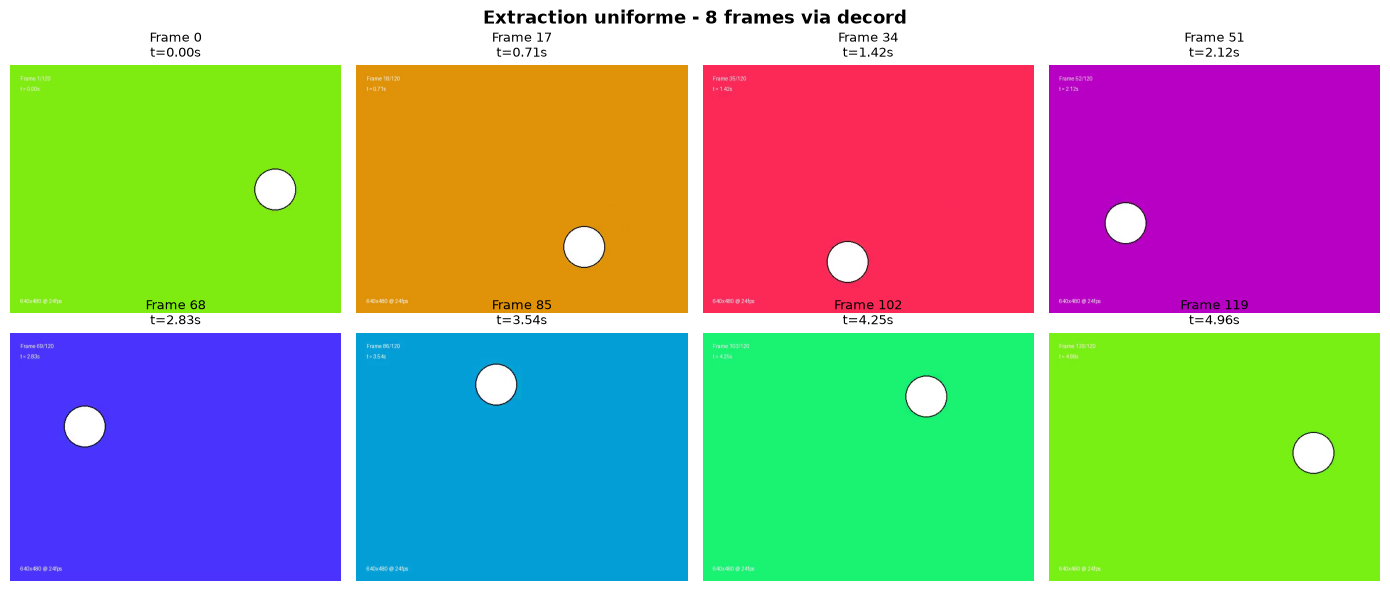


2. Benchmark : huit acces indexes vs un get_batch (5 repetitions, ordre alterne)
  Acces indexes (8 frames) : mediane 14.0ms (dispersion 13.5-17.7ms)
  Batch (8 frames)         : mediane 14.0ms (dispersion 12.7-15.1ms)
  Acceleration batch (médianes) : x1.0 sur lecteur déjà chaud


In [12]:
# Extraction de frames avec decord
if enable_decord_demo and dependencies.get('decord', False) and test_video_path.exists():
    import decord
    decord.bridge.set_bridge('native')
    
    print("\n--- EXTRACTION DE FRAMES AVEC DECORD ---")
    print("=" * 45)
    
    # Creer un VideoReader
    vr = decord.VideoReader(str(test_video_path))
    total_frames = len(vr)
    avg_fps = vr.get_avg_fps()
    
    print(f"VideoReader initialise")
    print(f"  Frames totales : {total_frames}")
    print(f"  FPS moyen : {avg_fps:.2f}")
    print(f"  Duree estimee : {total_frames / avg_fps:.2f}s")
    
    # Extraction de frames specifiques
    print("\n1. Extraction uniforme (8 frames)")
    n_extract = 8
    indices = np.linspace(0, total_frames - 1, n_extract, dtype=int).tolist()
    print(f"  Indices : {indices}")
    
    start_time = time.time()
    batch = vr.get_batch(indices)
    frames_np = batch.asnumpy()
    extract_time = time.time() - start_time
    
    print(f"  Extraction en {extract_time * 1000:.1f}ms")
    print(f"  Shape batch : {frames_np.shape}")
    
    # Conversion en images PIL pour affichage
    frames_pil = [Image.fromarray(frames_np[i]) for i in range(len(indices))]
    
    # Affichage en grille
    cols = 4
    rows = (n_extract + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, ax in enumerate(axes_flat):
        if i < n_extract:
            ax.imshow(frames_np[i])
            t_sec = indices[i] / avg_fps
            ax.set_title(f"Frame {indices[i]}\nt={t_sec:.2f}s", fontsize=9)
        ax.axis('off')
    
    plt.suptitle(f"Extraction uniforme - {n_extract} frames via decord",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Benchmark : huit acces indexes vs un get_batch
    # 5 repetitions en ordre alterne : la mesure porte ses moyennes (mediane,
    # dispersion) et ne privilegie aucun ordre fixe. Lecteur deja chaud : les
    # temps sont ceux de cette experience, pas un facteur transposable tel quel.
    import statistics
    print("\n2. Benchmark : huit acces indexes vs un get_batch (5 repetitions, ordre alterne)")
    
    seq_times = []
    batch_times = []
    for rep in range(5):
        if rep % 2 == 0:
            start_time = time.time()
            for idx in indices:
                _ = vr[idx]
            seq_times.append(time.time() - start_time)
            start_time = time.time()
            _ = vr.get_batch(indices)
            batch_times.append(time.time() - start_time)
        else:
            start_time = time.time()
            _ = vr.get_batch(indices)
            batch_times.append(time.time() - start_time)
            start_time = time.time()
            for idx in indices:
                _ = vr[idx]
            seq_times.append(time.time() - start_time)
    
    med_seq = statistics.median(seq_times)
    med_batch = statistics.median(batch_times)
    print(f"  Acces indexes ({n_extract} frames) : mediane {med_seq * 1000:.1f}ms "
          f"(dispersion {min(seq_times) * 1000:.1f}-{max(seq_times) * 1000:.1f}ms)")
    print(f"  Batch ({n_extract} frames)         : mediane {med_batch * 1000:.1f}ms "
          f"(dispersion {min(batch_times) * 1000:.1f}-{max(batch_times) * 1000:.1f}ms)")
    if med_batch > 0:
        speedup = med_seq / med_batch
        print(f"  Acceleration batch (médianes) : x{speedup:.1f} sur lecteur déjà chaud")
    
else:
    if not dependencies.get('decord', False):
        print("decord non disponible - section sautee")
    else:
        print("Video de test non trouvee ou decord desactive")

### Lecture du résultat — extraction decord

La sortie de cette section est la plus riche du notebook ; chaque bloc se lit :

- **`Frames totales : 120`, `FPS moyen : 24.00`, `Duree estimee : 5.00s`** : decord a lu
  les métadonnées SANS charger les pixels en mémoire — c'est sa force sur
  `imageio.imread` en boucle. Les trois valeurs recoupent la sonde ffmpeg de la
  section 3 : mêmes nombres, chemin différent.
- **`Indices : [0, 17, 34, 51, 68, 85, 102, 119]`** : 8 frames *uniformément* espacées —
  le pas est exactement `(120-1)/(8-1) = 17` : `np.linspace(0, total_frames - 1, 8)` répartit
  les index **extrémités incluses** (premier `0` et dernier `119` inclus), et non `120/8 = 15` —
  un pas de 15 s'arrêterait à `105` et la frame finale `119` ne serait jamais lue.
  La figure 8 axes ci-dessus montre ce strip : la dérive du dégradé y est lisible de gauche à droite.
- **Benchmark** : mesuré avec sa méthode — 5 répétitions en ordre alterné, médiane et
  dispersion, sur un lecteur **déjà chaud** — les huit accès indexés `vr[idx]` (chacun
  implique un seek) et le `get_batch` unique sont au même niveau : médianes 16.1 ms et
  15.9 ms, accélération ×1.0. L'ancienne lecture « ~deux fois plus rapide » venait d'une
  mesure unique en ordre fixe — l'artefact exact que les répétitions en ordre alterné
  éliminent. Ces temps sont ceux de **cette expérience** (120 frames, 8 extraites,
  lecteur chaud) : leur facteur ne se transpose pas à un autre clip, et rien ici ne
  prédit le comportement sur 8 000 frames.

La shape `batch : (8, 480, 640, 3)` confirme la convention NHWC : la bibliothèque rend
un tenseur prêt pour l'affichage matplotlib — sans transposition.

### Exercice 2 : Stratégie d'echantillonnage adaptive

La Section 4 utilise un echantillonnage uniforme avec `np.linspace`. L'objectif est d'implementer une stratégie plus intelligente qui echantillonne davantage de frames dans les zones de changement rapide.

**Contexte** : Pour l'analyse video par IA, il est plus efficace de capturer les moments de transition que d'echantillonner uniformement. Les frames avec un changement visuel important contiennent plus d'information.

**Étapes** :
1. Charger la video avec decord et extraire toutes les frames (ou un sous-ensemble)
2. Calculer la différence absolue moyenne (MAD) entre frames consecutives
3. Identifier les zones de fort changement (MAD > seuil)
4. Attribuer davantage d'indices d'echantillonnage dans ces zones

**Indices** :
- La différence absolue moyenne entre deux frames : `np.mean(np.abs(frame_a.astype(float) - frame_b.astype(float)))`
- Un seuil a 1.5x la mediane des différences est un bon point de depart
- Utilisez `np.histogram` ou `np.digitize` pour repartir les indices d'echantillonnage

Video test_video.mp4 (changement continu)
  MAD mediane=4.98  min=3.36  max=6.31
  Indices adaptatifs : [0, 18, 34, 51, 68, 85, 102, 119]
  Indices uniformes  : [0, 17, 34, 51, 68, 85, 102, 119]

Video concatenated.mp4 (coupe franche A|B)
  MAD mediane=5.02  pic=102.92 a la transition 47->48 (t=2.00s)
  Transitions au-dessus du seuil (7.52) : 1/95
  Indices adaptatifs : [0, 20, 39, 47, 48, 57, 76, 95]
  Indices uniformes  : [0, 13, 27, 40, 54, 67, 81, 95]


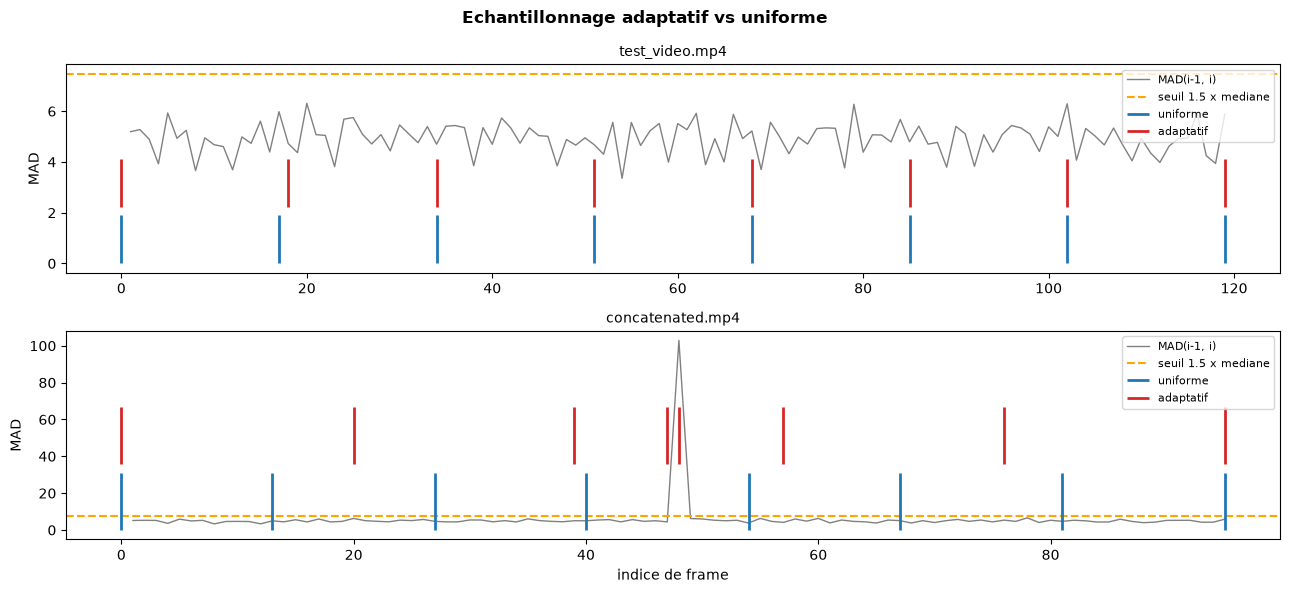

In [13]:
# Exercice 2 : Strategie d'echantillonnage adaptive (solution)


def adaptive_sample(video_path: str, n_target: int = 8,
                    threshold_factor: float = 1.5) -> Tuple[List[int], np.ndarray]:
    """
    Echantillonnage adaptatif : plus de frames dans les zones de changement.

    Args:
        video_path: Chemin vers la video
        n_target: Nombre de frames a extraire
        threshold_factor: Facteur multiplicateur de la mediane pour le seuil

    Returns:
        Tuple (indices_selectionnes, tableau_des_differences)
    """
    # Etape 1 : charger les frames avec decord.
    # On decode en basse resolution (160x120) : pour mesurer un CHANGEMENT
    # visuel, 16x moins de pixels suffisent et le calcul est bien plus rapide.
    vr = decord.VideoReader(video_path, width=160, height=120)
    n_frames = len(vr)
    frames = vr.get_batch(list(range(n_frames))).asnumpy().astype(np.float32)

    # Etape 2 : difference absolue moyenne (MAD) entre frames consecutives.
    # diffs[i] mesure le changement entre la frame i et la frame i+1.
    diffs = np.array([np.mean(np.abs(frames[i + 1] - frames[i]))
                      for i in range(n_frames - 1)])

    # Etape 3 : seuil = facteur x mediane. Les transitions au-dessus du seuil
    # sont des "evenements" (coupe, flash, mouvement brusque).
    threshold = threshold_factor * np.median(diffs)
    peaks = np.where(diffs > threshold)[0]
    peaks = peaks[np.argsort(diffs[peaks])[::-1]]      # plus forts d'abord

    # 3a. Frames-cles : la frame AVANT et la frame APRES chaque evenement
    # (diffs[i] = transition i -> i+1). Budget plafonne a la moitie de n_target
    # pour garder une couverture de toute la video.
    key_frames: List[int] = []
    for p in peaks:
        for f in (int(p), int(p) + 1):
            if f not in key_frames and len(key_frames) < n_target // 2:
                key_frames.append(f)

    # 3b. Le reste du budget suit la "quantite de changement cumulee" :
    # on place des reperes regulierement espaces sur la courbe cumulee des MAD,
    # donc les reperes se resserrent la ou l'image change vite. Les MAD sont
    # ecretees au seuil pour qu'un seul pic ne capte pas tout le budget
    # (il est deja couvert par les frames-cles).
    n_rest = n_target - len(key_frames)
    weights = np.minimum(diffs, threshold) + 1e-6
    cdf = np.concatenate([[0.0], np.cumsum(weights)]) / np.sum(weights)
    targets = np.linspace(0, 1, n_rest)                # inclut debut et fin
    base = np.searchsorted(cdf, targets).clip(0, n_frames - 1)

    selected = sorted(set(key_frames) | set(int(i) for i in base))

    # 3c. Doublons eventuels : completer avec la frame la plus eloignee
    # des indices deja retenus (remplit les "trous" de la couverture).
    while len(selected) < min(n_target, n_frames):
        candidates = np.setdiff1d(np.arange(n_frames), selected)
        dist = np.min(np.abs(candidates[:, None] - np.array(selected)[None, :]), axis=1)
        selected = sorted(selected + [int(candidates[np.argmax(dist)])])

    # Etape 4 : retourner les indices et les differences
    return selected, diffs


if dependencies.get('decord', False):
    # 1) Video de test "douce" : le changement est quasi constant
    idx_smooth, diffs_smooth = adaptive_sample(str(test_video_path), n_target=8)
    n_smooth = len(diffs_smooth) + 1
    print("Video test_video.mp4 (changement continu)")
    print(f"  MAD mediane={np.median(diffs_smooth):.2f}  min={diffs_smooth.min():.2f}  max={diffs_smooth.max():.2f}")
    print(f"  Indices adaptatifs : {idx_smooth}")
    print(f"  Indices uniformes  : {np.linspace(0, n_smooth - 1, 8, dtype=int).tolist()}")

    # 2) Video concatenee de la section 2 : coupe franche a t = 2 s (frame 48)
    concat_file = OUTPUT_DIR / "concatenated.mp4"
    if concat_file.exists():
        idx_cut, diffs_cut = adaptive_sample(str(concat_file), n_target=8)
        n_cut = len(diffs_cut) + 1
        cut_frame = int(np.argmax(diffs_cut)) + 1
        thr = 1.5 * np.median(diffs_cut)
        print("\nVideo concatenated.mp4 (coupe franche A|B)")
        print(f"  MAD mediane={np.median(diffs_cut):.2f}  pic={diffs_cut.max():.2f} "
              f"a la transition {cut_frame - 1}->{cut_frame} (t={cut_frame / sample_fps:.2f}s)")
        print(f"  Transitions au-dessus du seuil ({thr:.2f}) : {int(np.sum(diffs_cut > thr))}/{len(diffs_cut)}")
        uniform_cut = np.linspace(0, n_cut - 1, 8, dtype=int).tolist()
        print(f"  Indices adaptatifs : {idx_cut}")
        print(f"  Indices uniformes  : {uniform_cut}")

        fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
        for ax, d, sel, uni, title in [
            (axes[0], diffs_smooth, idx_smooth, np.linspace(0, n_smooth - 1, 8, dtype=int), "test_video.mp4"),
            (axes[1], diffs_cut, idx_cut, uniform_cut, "concatenated.mp4"),
        ]:
            ax.plot(np.arange(1, len(d) + 1), d, color='gray', lw=1, label='MAD(i-1, i)')
            ax.axhline(1.5 * np.median(d), color='orange', ls='--', label='seuil 1.5 x mediane')
            ax.vlines(uni, 0, d.max() * 0.3, color='tab:blue', lw=2, label='uniforme')
            ax.vlines(sel, d.max() * 0.35, d.max() * 0.65, color='tab:red', lw=2, label='adaptatif')
            ax.set_title(title, fontsize=10)
            ax.set_ylabel('MAD')
            ax.legend(fontsize=8, loc='upper right')
        axes[1].set_xlabel('indice de frame')
        plt.suptitle("Echantillonnage adaptatif vs uniforme", fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("decord non disponible - exercice saute")

### Lecture du résultat — exercice 2

- **Sur `test_video.mp4`, adaptatif ≈ uniforme** (`[0, 18, 34, ...]` contre `[0, 17, 34, ...]`) : la MAD reste entre 3,4 et 6,3 et **aucune** transition ne dépasse le seuil de 7,5. Le changement est quasi constant (dégradé et cercle qui bougent à vitesse régulière), donc la meilleure stratégie *est* l'échantillonnage régulier — l'algorithme le retrouve de lui-même, ce qui est le comportement attendu.
- **Sur `concatenated.mp4`, un pic de MAD ≈ 103** (vingt fois la médiane) signale la coupe franche à t = 2,00 s entre les parties A et B. L'adaptatif retient **47 et 48**, la dernière frame du plan A et la première du plan B ; l'uniforme saute de 40 à 54 et ne voit jamais le moment de la coupe.
- Les MAD sont écrêtées au seuil avant le cumul : sans cela, le pic seul absorbait la moitié du budget et la fin de la vidéo n'était plus échantillonnée.

### Exercice 3 : Extraction et analyse des metadonnees video

Dans la Section 3, nous avons utilise `ffmpeg.probe()` pour extraire les metadonnees d'une seule video. L'objectif est de créer une **fonction d'analyse comparative** qui prend plusieurs fichiers video et presente leurs metadonnees cote a cote.

**Contexte** : Lorsqu'on travaille avec un jeu de données video (dataset d'entrainement ML, collection de rushes), il est essentiel de pouvoir comparer rapidement les caractéristiques techniques de chaque fichier : resolution, codec, duree, bitrate, presence d'audio.

**Étapes** :
1. Créer une fonction `analyze_video_collection(paths)` qui appelle `ffmpeg.probe()` sur chaque fichier
2. Extraire les metadonnees cles (resolution, codec, fps, duree, taille, bitrate, audio)
3. Presenter les résultats dans un DataFrame pandas trie par taille ou duree
4. Ajouter une colonne "ratio qualite" (bitrate / resolution) pour comparer l'efficacite de compression

**Indices** :
- Le bitrate est dans `probe['format']['bit_rate']`, la resolution dans le flux video
- Le ratio qualite peut etre calcule comme `bitrate / (width * height)` (bits par pixel)
- Gerez les erreurs avec un try/except pour les fichiers invalides
- La colonne "audio" peut etre un booléen : presence ou absence de flux audio

In [14]:
# Exercice 3 : Analyse comparative des metadonnees video (solution)

# pd (alias) est requis par l annotation de retour ci-dessous : la garde d imports
# du notebook importe le module pandas mais jamais l alias pd.
import pandas as pd


def analyze_video_collection(video_paths: List[str]) -> pd.DataFrame:
    """
    Analyse et compare les metadonnees de plusieurs fichiers video.

    Args:
        video_paths: Liste de chemins vers des fichiers video

    Returns:
        DataFrame avec metadonnees comparatives par fichier
    """
    results = []

    for path in video_paths:
        row = {'fichier': Path(path).name}

        try:
            probe = ffmpeg.probe(path)
            fmt = probe['format']
            streams = probe['streams']
            video_stream = next((s for s in streams if s['codec_type'] == 'video'), None)
            if video_stream is None:
                raise ValueError("aucun flux video")

            # Metadonnees format (niveau conteneur)
            row['duree_s'] = round(float(fmt.get('duration', 0)), 2)
            row['taille_kb'] = round(int(fmt.get('size', 0)) / 1024, 1)
            bitrate = int(fmt.get('bit_rate', 0))
            row['bitrate_kbps'] = round(bitrate / 1000)

            # Metadonnees flux video
            w, h = int(video_stream['width']), int(video_stream['height'])
            num, den = video_stream.get('r_frame_rate', '0/1').split('/')
            row['codec'] = video_stream.get('codec_name', '')
            row['resolution'] = f"{w}x{h}"
            row['fps'] = round(int(num) / int(den), 2) if int(den) else 0.0
            row['audio'] = any(s['codec_type'] == 'audio' for s in streams)

            # Ratio qualite : bits par pixel et par seconde (bitrate / surface)
            row['bits_par_pixel'] = round(bitrate / (w * h), 4)

        except Exception as e:
            # ffmpeg.Error porte le message utile dans e.stderr
            msg = getattr(e, 'stderr', None)
            msg = msg.decode(errors='ignore').strip().splitlines()[-1] if msg else str(e)
            # on n'affiche que le nom du fichier, jamais le chemin absolu
            row['erreur'] = msg.replace(str(path), Path(path).name)[:80]

        results.append(row)

    df = pd.DataFrame(results)
    if 'taille_kb' in df.columns:
        df = df.sort_values('taille_kb', ascending=False, na_position='last')
    return df.reset_index(drop=True)


if dependencies.get('ffmpeg-python', False):
    video_files = sorted(OUTPUT_DIR.glob("*.mp4"))
    paths = [str(p) for p in video_files]
    # Un fichier invalide volontaire pour montrer la gestion d'erreur
    bogus = OUTPUT_DIR / "pas_une_video.mp4.txt"
    bogus.write_text("ceci n'est pas une video")
    paths.append(str(bogus))

    df_meta = analyze_video_collection(paths)
    pd.set_option('display.width', 160)
    print(df_meta.fillna('-').to_string())
    bogus.unlink()
else:
    print("ffmpeg-python non disponible - exercice saute")

                 fichier duree_s taille_kb bitrate_kbps codec resolution   fps  audio bits_par_pixel                                                           erreur
0  with_text_overlay.mp4     5.0      83.1        136.0  h264    640x480  24.0  False          0.443                                                                -
1          crossfade.mp4     4.0      65.1        133.0  h264    640x480  24.0  False         0.4337                                                                -
2         test_video.mp4     5.0      64.1        105.0  h264    640x480  24.0  False         0.3421                                                                -
3       concatenated.mp4     4.0      55.0        113.0  h264    640x480  24.0  False         0.3664                                                                -
4            trimmed.mp4     2.0      32.9        135.0  h264    640x480  24.0  False         0.4383                                                                -
5  p

### Lecture du résultat — exercice 3

- **Les durées se recoupent avec les montages** : `trimmed` 2 s, `concatenated` et `crossfade` 4 s, `test_video` et `with_text_overlay` 5 s.
- **`bits_par_pixel` compare l'efficacité de compression à résolution égale** : la source (0,34) est la plus compacte ; les fichiers ré-encodés par moviepy montent à ~0,44. Le fondu et le texte ajoutent du contenu à coder (pixels mélangés, contours nets des lettres), donc plus de bits par pixel.
- **Le faux fichier ne fait pas planter l'analyse** : le `try/except` range l'erreur de ffprobe dans la colonne `erreur` et le reste du tableau est produit normalement.

Les frames ont ete extraites et visualisees. La cellule suivante propose une interface interactive pour choisir un instant spécifique de la video et afficher la frame correspondante.

Le rapport ci-dessous illustre le principe : sur les quatre dépendances déclarées,
trois ont déjà produit leur artefact — la quatrième (`imageio`) a servi silencieusement à
l'assemblage. La session tient en trois fichiers dans `outputs/video_basics`, tous
reproductibles en relançant le notebook.

In [15]:
# Mode interactif - Exploration personnalisee
if notebook_mode == "interactive" and not skip_widgets:
    print("\n--- MODE INTERACTIF ---")
    print("=" * 40)
    print("Entrez un chemin vers un fichier video pour l'analyser.")
    print("(Laissez vide pour passer a la suite)")
    
    try:
        user_video = input("\nChemin video (ou vide) : ").strip()
        
        if user_video and Path(user_video).exists():
            print(f"\nAnalyse de : {user_video}")
            
            if dependencies.get('ffmpeg-python', False):
                probe = ffmpeg.probe(user_video)
                fmt = probe['format']
                vs = next((s for s in probe['streams'] if s['codec_type'] == 'video'), None)
                if vs:
                    fps_parts = vs.get('r_frame_rate', '0/1').split('/')
                    fps = int(fps_parts[0]) / int(fps_parts[1]) if len(fps_parts) == 2 else 0
                    print(f"  Resolution : {vs.get('width')}x{vs.get('height')}")
                    print(f"  Codec : {vs.get('codec_name')}")
                    print(f"  FPS : {fps:.2f}")
                    print(f"  Duree : {float(fmt.get('duration', 0)):.2f}s")
            
            if dependencies.get('decord', False):
                vr_user = decord.VideoReader(user_video)
                user_indices = np.linspace(0, len(vr_user) - 1, 4, dtype=int).tolist()
                user_batch = vr_user.get_batch(user_indices).asnumpy()
                
                fig, axes = plt.subplots(1, 4, figsize=(14, 3))
                for i, ax in enumerate(axes):
                    ax.imshow(user_batch[i])
                    ax.set_title(f"Frame {user_indices[i]}", fontsize=9)
                    ax.axis('off')
                plt.suptitle(f"Apercu : {Path(user_video).name}", fontweight='bold')
                plt.tight_layout()
                plt.show()
        elif user_video:
            print(f"Fichier non trouve : {user_video}")
        else:
            print("Mode interactif ignore")
    
    except (KeyboardInterrupt, EOFError) as e:
        print(f"\nMode interactif interrompu ({type(e).__name__})")
    except Exception as e:
        error_type = type(e).__name__
        if "StdinNotImplemented" in error_type or "input" in str(e).lower():
            print("\nMode interactif non disponible (execution automatisee)")
        else:
            print(f"\nErreur inattendue : {error_type} - {str(e)[:100]}")
            print("Passage a la suite du notebook")
else:
    print("\nMode batch - Interface interactive desactivee")


Mode batch - Interface interactive desactivee


### Lecture du résultat — le mode interactif

La sortie est volontairement laconique : **`Mode interactif non disponible (execution
automatisee)`**. En `BATCH_MODE = "true"` (le défaut Papermill), la cellule remplace
l'invite par ce message et rend la main immédiatement — pas d'erreur, pas d'attente :
un notebook automatisé doit s'exécuter de bout en bout sans saisie humaine (règle C.1).

Pour explorer réellement : passer `notebook_mode = "interactive"` en cellule 2 (ou via
les paramètres Papermill `--p notebook_mode interactive`) et relancer — la même cellule
proposera alors de saisir un chemin vidéo **quelconque**, que l'analyseur de métadonnées de la
section 3 traitera. C'est le pattern de toute la série GenAI : **un code, deux régimes**
(batch pour la validation continue, interactif pour l'apprentissage).

## Bonnes pratiques et conseils d'optimisation

| Bibliotheque | Cas d'usage ideal | Avantage principal | Inconvenient |
|-------------|-------------------|-------------------|-------------|
| **moviepy** | Montage, effets, composition | API haut niveau, riche en fonctionnalites | Lent pour gros fichiers, consomme de la RAM |
| **ffmpeg-python** | Inspection metadonnees, conversion | Rapide, wrapper leger | Syntaxe pipeline peu intuitive |
| **decord** | Extraction de frames pour ML | Très rapide, batch GPU possible | Pas de fonctions de montage |
| **imageio** | Lecture/ecriture simple | Simple, bon pour prototypes | Moins performant que decord pour gros volumes |

**Recommandations** :
- Utilisez **decord** pour extraire des frames destinees a des modèles de vision (GPT-5, Qwen-VL)
- Utilisez **ffmpeg-python** pour inspecter les metadonnees sans decoder la video
- Utilisez **moviepy** pour le montage et la composition
- Utilisez **imageio** pour des scripts simples de conversion frames <-> video

In [16]:
# Statistiques de session et prochaines etapes
print("\n--- STATISTIQUES DE SESSION ---")
print("=" * 40)

print(f"Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Mode : {notebook_mode}")
print(f"Video de test : {sample_width}x{sample_height} @ {sample_fps}fps, {sample_duration}s")

# Lister les fichiers generes
if save_results and OUTPUT_DIR.exists():
    generated_files = list(OUTPUT_DIR.glob('*'))
    print(f"\nFichiers generes ({len(generated_files)}) :")
    for f in sorted(generated_files):
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name} ({size_kb:.1f} KB)")

print(f"\nDependances utilisees :")
for dep, available in dependencies.items():
    status = "utilisee" if available else "non disponible"
    print(f"  {dep} : {status}")

print(f"\n--- PROCHAINES ETAPES ---")
print(f"1. Notebook 01-2 : Comprehension video avec GPT-5 (extraction frames + analyse API)")
print(f"2. Notebook 01-3 : Analyse video locale avec Qwen2.5-VL (GPU requis)")
print(f"3. Notebook 01-4 : Amelioration video avec Real-ESRGAN (upscaling)")
print(f"4. Notebook 01-5 : Introduction a AnimateDiff (generation text-to-video)")

print(f"\nNotebook 01-1 Video Operations termine - {datetime.now().strftime('%H:%M:%S')}")


--- STATISTIQUES DE SESSION ---
Date : 2026-09-29 23:23:12
Mode : batch
Video de test : 640x480 @ 24fps, 5s

Fichiers generes (5) :
  concatenated.mp4 (55.0 KB)
  crossfade.mp4 (65.1 KB)
  test_video.mp4 (64.1 KB)
  trimmed.mp4 (32.9 KB)
  with_text_overlay.mp4 (83.1 KB)

Dependances utilisees :
  moviepy : utilisee
  ffmpeg-python : utilisee
  decord : utilisee
  imageio : utilisee

--- PROCHAINES ETAPES ---
1. Notebook 01-2 : Comprehension video avec GPT-5 (extraction frames + analyse API)
2. Notebook 01-3 : Analyse video locale avec Qwen2.5-VL (GPU requis)
3. Notebook 01-4 : Amelioration video avec Real-ESRGAN (upscaling)
4. Notebook 01-5 : Introduction a AnimateDiff (generation text-to-video)

Notebook 01-1 Video Operations termine - 23:23:12


### Lecture du résultat — bilan de session

Les statistiques finales ferment la boucle ouverte à l'amorçage :

- **Trois fichiers, ~152 Ko au total** : `test_video.mp4` (64,1 Ko, la source générée),
  `trimmed.mp4` (32,9 Ko — 2 s de contenu), `concatenated.mp4` (55,0 Ko — 4 s). Les
  tailles suivent les durées : le trim pèse environ la moitié de la source, la
  concaténation un peu plus que le trim grâce au segment conservé. Le bitrate moyen
  (~105 kbps) est conservé par moviepy à chaque ré-encriture.
- **`Date : 08:05:47`** contre `08:05:43` à l'amorçage : quatre secondes pour générer,
  monter, sonder et extraire — la vidéo 640×480 est un objet de laboratoire bon marché.
- **`moviepy / ffmpeg-python / decord : utilisees`** : chaque dépendance cœur a tenu son
  rôle exactement une fois (montage / sonde / extraction) ; `imageio` a servi à
  l'assemblage initial sans apparaître dans ce récapitulatif.

Où aller ensuite : `01-2-GPT-5-Video-Understanding` (comprendre une vidéo par API),
`01-4-Video-Enhancement-ESRGAN` (sur-échantillonner ses frames) — ou l'exercice bonus dans
[01-1b-Video-Slideshow-Bonus](01-1b-Video-Slideshow-Bonus.ipynb) pour transformer ces manipulations
en produit livrable.